In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12
N_SEGS = 6
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True, 
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i = params[i]
        try:
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS))
        except Exception:
            pass
    return out


def prior_transform(u):
    logm1lim = [5.94889, 6.03054]
    logm2lim = [0.99336, 1.13038]
    alim = [0.62652, 0.99000]
    p0lim = [8.74104, 9.68094]
    e0lim = [0.37427, 0.41300]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.94889, 6.03054]
    logm2lim = [0.99336, 1.13038]
    alim = [0.62652, 0.99000]
    p0lim = [8.74104, 9.68094]
    e0lim = [0.37427, 0.41300]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=5s, T=1.0yr, TDI gen=1, N_segs=6
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [ ]:
dir_scratch='/scratch/e1498138'

filepath=f'{dir_scratch}/paris3_sc/int_1yr_s6/sampler_state.pkl'


In [ ]:
sampler = parismc.Sampler.load_state(filepath)

In [4]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.49157086, 0.01273051, 0.14515951, 0.38462109, 0.80901484],
        [0.49112366, 0.01470559, 0.13424991, 0.38230442, 0.82997419],
        [0.48455132, 0.02262066, 0.14504139, 0.38676298, 0.83114079],
        ...,
        [0.76581622, 0.11103885, 0.26012016, 0.14437557, 0.48188222],
        [0.64171085, 0.0544246 , 0.20433999, 0.26075777, 0.60618032],
        [0.61684788, 0.08178486, 0.18633201, 0.32114901, 0.585481  ]]),
 array([[ 0.44408533,  0.18976258,  0.06904138,  0.56582702,  0.24338745],
        [ 0.44075394,  0.18465527,  0.08253134,  0.58694292,  0.24809684],
        [ 0.44160465,  0.19137156,  0.06174123,  0.56678768,  0.25652203],
        ...,
        [ 0.33746712,  0.14942988,  1.10655435,  0.47390589, -0.18883018],
        [ 0.82242258,  1.32135409, -0.19769867, -0.35139703,  0.99159747],
        [-0.11556391,  0.3940124 ,  0.6729325 ,  0.10126701,  0.67597061]])]

In [5]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([15.93420347, 11.34033171, 13.06241204, ..., 23.59485695,
        17.62432307, 18.8883866 ]),
 array([14.07928385, 11.5728095 , 13.3763234 , ...,        -inf,
               -inf,        -inf])]

In [18]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list[0])].reshape(1, -1))
maxld_pt1

array([[5.98953125, 0.99462188, 0.67867848, 9.12211995, 0.40462346]])

In [19]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list[0])].reshape(1, -1))
maxld_pt2

array([[5.97816451, 1.00452349, 0.65439797, 9.28733902, 0.3908914 ]])

In [20]:
log_density([param_true])

array([28.53035408])

In [21]:
log_density(maxld_pt1), log_density(maxld_pt2)

(array([27.8089039]), array([11.39697272]))

In [9]:
param_ranges = [(5.94889, 6.03054),
                (0.99336, 1.13038),
                (0.62652, 0.99000),
                (8.74104, 9.68094),
                (0.37427, 0.41300)
                ]
param_ranges

[(5.94889, 6.03054),
 (0.99336, 1.13038),
 (0.62652, 0.99),
 (8.74104, 9.68094),
 (0.37427, 0.413)]

In [10]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

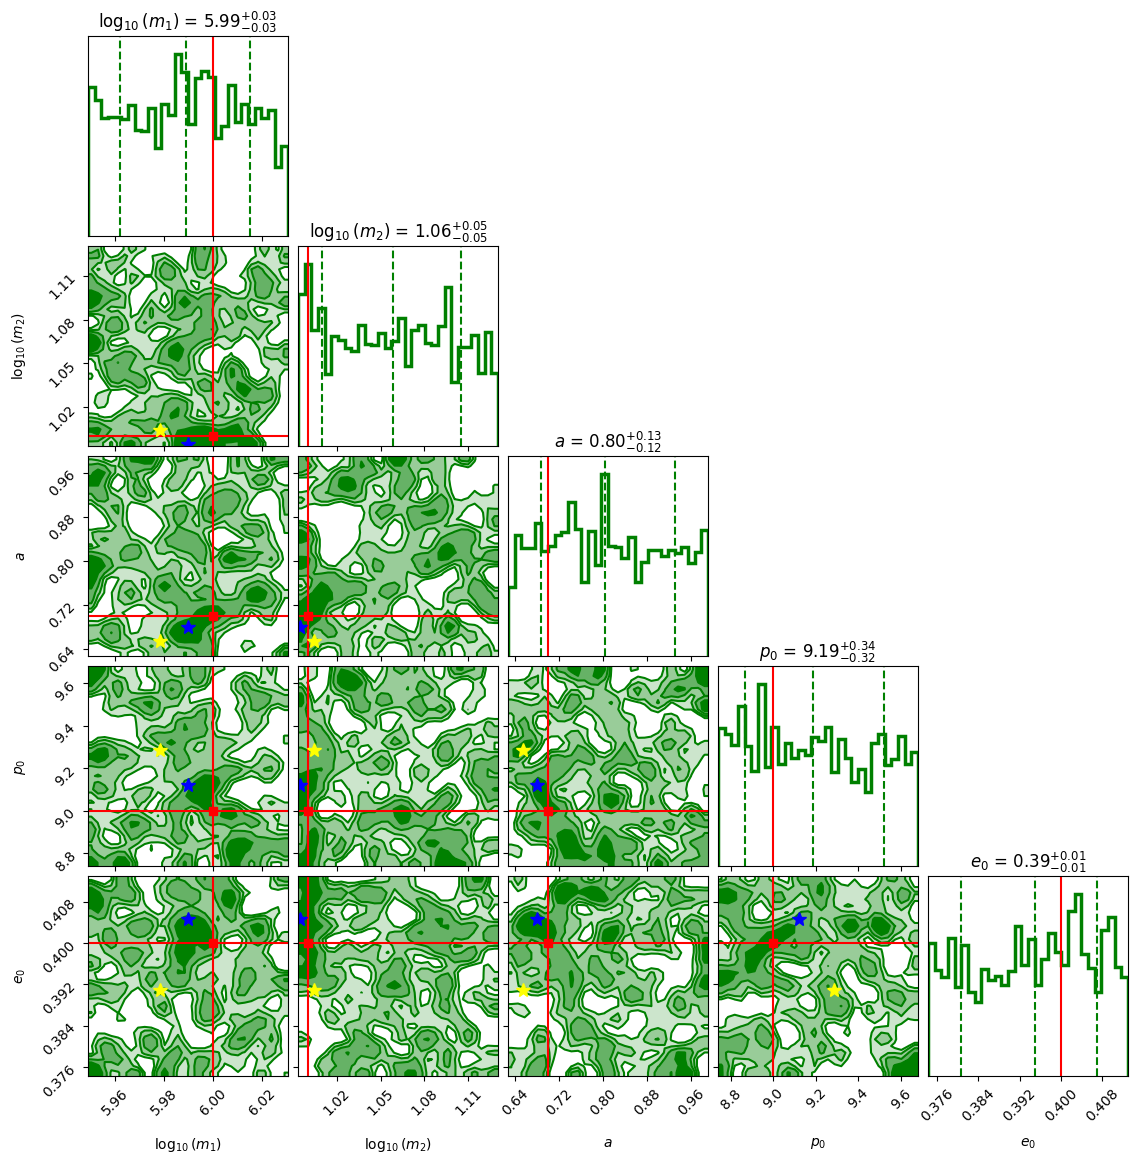

In [23]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt2.reshape(1, -1), 
                       color='yellow', marker='*', ms=10, 
                       reverse=False)

In [12]:
sampler.now_covariances

[array([[ 0.01401605,  0.00373358,  0.00644977, -0.01431654, -0.01187989],
        [ 0.00373358,  0.00128667,  0.00164253, -0.00361556, -0.00381186],
        [ 0.00644977,  0.00164253,  0.00298961, -0.00664326, -0.005289  ],
        [-0.01431654, -0.00361556, -0.00664326,  0.01495917,  0.01198293],
        [-0.01187989, -0.00381186, -0.005289  ,  0.01198293,  0.01211784]]),
 array([[ 2.60418826e-01,  4.97513122e-03, -1.72677698e-03,
         -1.85798202e-02, -4.23967543e-03],
        [ 4.97513122e-03,  2.99464877e-01, -2.95335435e-04,
         -2.09489235e-02, -2.27024416e-02],
        [-1.72677698e-03, -2.95335435e-04,  2.09683553e-01,
         -2.99932049e-03, -1.42662244e-02],
        [-1.85798202e-02, -2.09489235e-02, -2.99932049e-03,
          2.95869303e-01, -1.25528294e-02],
        [-4.23967543e-03, -2.27024416e-02, -1.42662244e-02,
         -1.25528294e-02,  3.19598964e-01]])]

In [24]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[5.98953125, 0.99462188, 0.67867848, 9.12211995, 0.40462346]])

In [25]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [26]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [27]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [28]:
import matplotlib.pyplot as plt

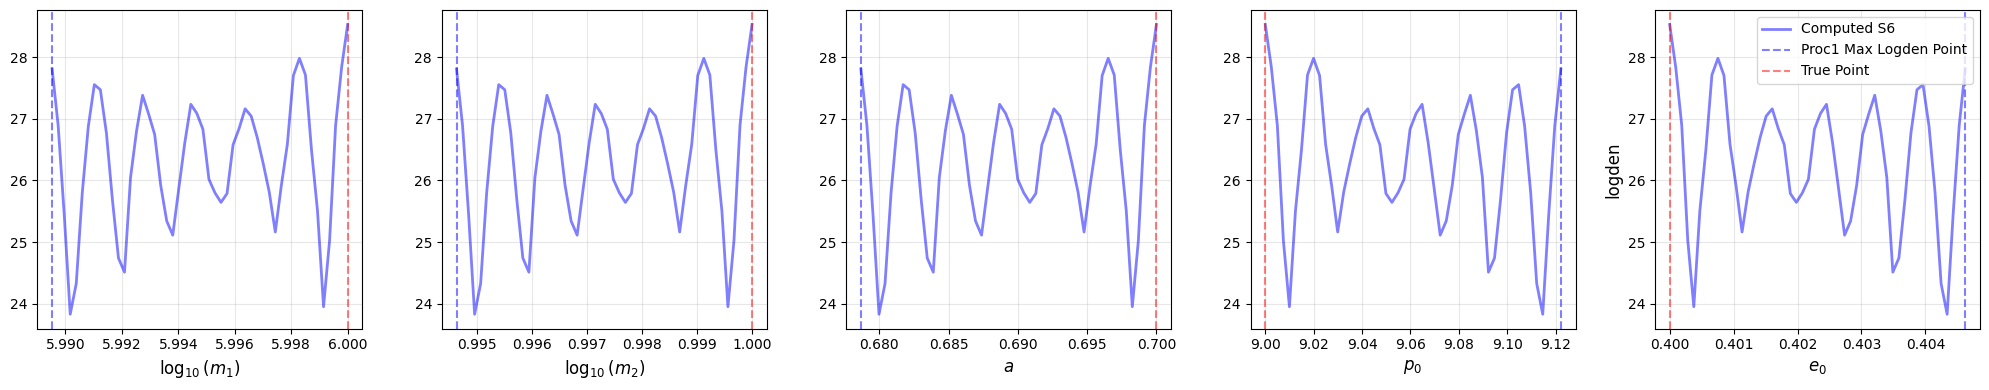

In [29]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed S6')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [30]:
proc2_maxld_pt = maxld_pt2.copy()
proc2_maxld_pt

array([[5.97816451, 1.00452349, 0.65439797, 9.28733902, 0.3908914 ]])

In [31]:
# connect two highest logden pts

proc2_maxld_pt_1d = proc2_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc2 = proc2_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc2_maxld_pt_1d)[:, np.newaxis]


In [32]:
logden_theory_proc2 = []
logden_theory_proc2.append(log_density(np.array(line_points_proc2).T))


In [33]:
logden_theory_proc2 = np.array(logden_theory_proc2).flatten()


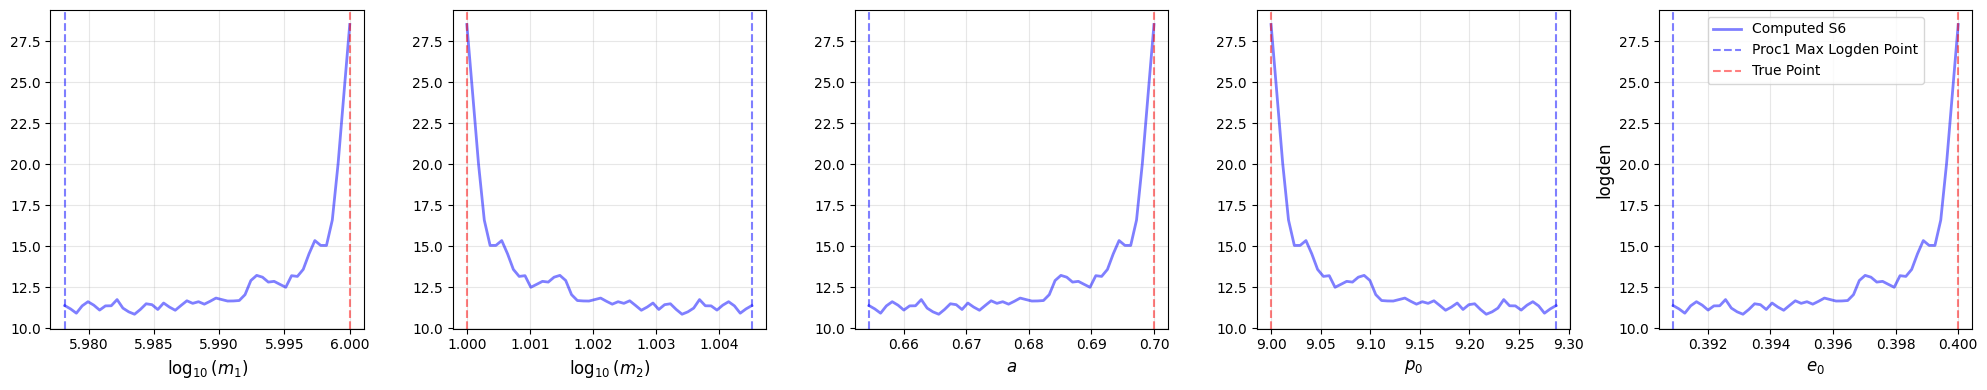

In [34]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    ax.plot(line_points_proc2[dim], logden_theory_proc2, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed S6')


    # Mark the max likelihood points
    ax.axvline(proc2_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
